In [2]:
import pandas as pd
import numpy as np

# Create dataset
data = {
    'math score': np.random.randint(60, 80, 30),
    'reading score': np.random.randint(75, 95, 30),
    'writing score': np.random.randint(60, 80, 30),
    'placement score': np.random.randint(75, 100, 30),
    'club join year': np.random.randint(2018, 2022, 30)
}

df = pd.DataFrame(data)

# Create placement offer count based on placement score
df['placement offer count'] = np.where(df['placement score'] > 85, 3,
                              np.where(df['placement score'] > 75, 2, 1))

# Show dataset
df.head()

,math score,reading score,writing score,placement score,club join year,placement offer count
0,61,88,61,80,2021,2
1,69,83,64,77,2019,2
2,72,92,60,83,2020,2
3,79,81,68,87,2019,3
4,61,82,74,99,2021,3


In [3]:
# Add missing values randomly
df.loc[5, 'math score'] = np.nan
df.loc[10, 'reading score'] = np.nan
df.loc[15, 'writing score'] = np.nan

# Add inconsistencies (out of range values)
df.loc[2, 'math score'] = 120   # should be 60-80
df.loc[7, 'placement score'] = 30  # should be 75-100

# Show dataset
df.head(15)

,math score,reading score,writing score,placement score,club join year,placement offer count
0,61.0,88.0,61.0,80,2021,2
1,69.0,83.0,64.0,77,2019,2
2,120.0,92.0,60.0,83,2020,2
3,79.0,81.0,68.0,87,2019,3
4,61.0,82.0,74.0,99,2021,3
5,NaN,75.0,78.0,90,2020,3
6,66.0,78.0,78.0,88,2021,3
7,62.0,90.0,60.0,30,2021,3
8,77.0,89.0,77.0,84,2020,2
9,65.0,78.0,75.0,84,2019,2


In [4]:
# Check missing values (True = missing)
print(df.isnull())

# Check column-wise missing values
print("\nMissing values count:\n")
print(df.isnull().sum())

    math score  reading score  writing score  placement score  club join year  \
0        False          False          False            False           False   
1        False          False          False            False           False   
2        False          False          False            False           False   
3        False          False          False            False           False   
4        False          False          False            False           False   
5         True          False          False            False           False   
6        False          False          False            False           False   
7        False          False          False            False           False   
8        False          False          False            False           False   
9        False          False          False            False           False   
10       False           True          False            False           False   
11       False          Fals

In [5]:
print(df.notnull())

    math score  reading score  writing score  placement score  club join year  \
0         True           True           True             True            True   
1         True           True           True             True            True   
2         True           True           True             True            True   
3         True           True           True             True            True   
4         True           True           True             True            True   
5        False           True           True             True            True   
6         True           True           True             True            True   
7         True           True           True             True            True   
8         True           True           True             True            True   
9         True           True           True             True            True   
10        True          False           True             True            True   
11        True           Tru

In [6]:
# Fill missing values with mean
df['math score'].fillna(df['math score'].mean(), inplace=True)
df['reading score'].fillna(df['reading score'].mean(), inplace=True)
df['writing score'].fillna(df['writing score'].mean(), inplace=True)

df.head(15)

C:\Users\Akshay\AppData\Local\Temp\ipykernel_20592\469417229.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['math score'].fillna(df['math score'].mean(), inplace=True)
C:\Users\Akshay\AppData\Local\Temp\ipykernel_20592\469417229.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

,math score,reading score,writing score,placement score,club join year,placement offer count
0,61.000000,88.000000,61.0,80,2021,2
1,69.000000,83.000000,64.0,77,2019,2
2,120.000000,92.000000,60.0,83,2020,2
3,79.000000,81.000000,68.0,87,2019,3
4,61.000000,82.000000,74.0,99,2021,3
5,70.862069,75.000000,78.0,90,2020,3
6,66.000000,78.000000,78.0,88,2021,3
7,62.000000,90.000000,60.0,30,2021,3
8,77.000000,89.000000,77.0,84,2020,2
9,65.000000,78.000000,75.0,84,2019,2


In [7]:
# Drop rows with any missing value
df_drop = df.dropna()

df_drop.head()

,math score,reading score,writing score,placement score,club join year,placement offer count
0,61.0,88.0,61.0,80,2021,2
1,69.0,83.0,64.0,77,2019,2
2,120.0,92.0,60.0,83,2020,2
3,79.0,81.0,68.0,87,2019,3
4,61.0,82.0,74.0,99,2021,3


In [8]:
# Replace any remaining NaN with -99
df_replace = df.replace(np.nan, -99)

df_replace.head()

,math score,reading score,writing score,placement score,club join year,placement offer count
0,61.0,88.0,61.0,80,2021,2
1,69.0,83.0,64.0,77,2019,2
2,120.0,92.0,60.0,83,2020,2
3,79.0,81.0,68.0,87,2019,3
4,61.0,82.0,74.0,99,2021,3


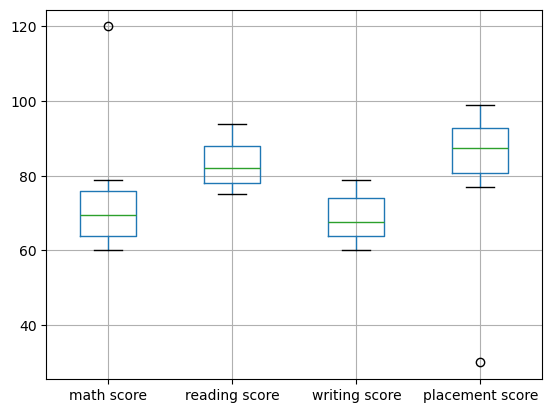

In [9]:
import matplotlib.pyplot as plt

# Draw boxplot
cols = ['math score', 'reading score', 'writing score', 'placement score']
df.boxplot(cols)

plt.show()

In [10]:
import numpy as np

# Find outliers (example conditions)
print("Math score outliers:", np.where(df['math score'] > 100))
print("Placement score outliers:", np.where(df['placement score'] < 50))

Math score outliers: (array([2]),)
Placement score outliers: (array([7]),)


In [11]:
# Remove outliers (example: math score > 100)
df_clean = df[df['math score'] <= 100]

df_clean.head()

,math score,reading score,writing score,placement score,club join year,placement offer count
0,61.000000,88.0,61.0,80,2021,2
1,69.000000,83.0,64.0,77,2019,2
3,79.000000,81.0,68.0,87,2019,3
4,61.000000,82.0,74.0,99,2021,3
5,70.862069,75.0,78.0,90,2020,3


In [12]:
# Cap math score at 90th percentile
upper_limit = np.percentile(df['math score'], 90)

df['math score'] = np.where(df['math score'] > upper_limit,
                           upper_limit,
                           df['math score'])

df.head()

,math score,reading score,writing score,placement score,club join year,placement offer count
0,61.0,88.0,61.0,80,2021,2
1,69.0,83.0,64.0,77,2019,2
2,79.0,92.0,60.0,83,2020,2
3,79.0,81.0,68.0,87,2019,3
4,61.0,82.0,74.0,99,2021,3


In [13]:
# Convert join year to duration (assume current year = 2026)
df['duration'] = 2026 - df['club join year']

df.head()

,math score,reading score,writing score,placement score,club join year,placement offer count,duration
0,61.0,88.0,61.0,80,2021,2,5
1,69.0,83.0,64.0,77,2019,2,7
2,79.0,92.0,60.0,83,2020,2,6
3,79.0,81.0,68.0,87,2019,3,7
4,61.0,82.0,74.0,99,2021,3,5


In [14]:
# Apply log transformation on math score
df['log_math'] = np.log10(df['math score'])

df.head()

,math score,reading score,writing score,placement score,club join year,placement offer count,duration,log_math
0,61.0,88.0,61.0,80,2021,2,5,1.785330
1,69.0,83.0,64.0,77,2019,2,7,1.838849
2,79.0,92.0,60.0,83,2020,2,6,1.897627
3,79.0,81.0,68.0,87,2019,3,7,1.897627
4,61.0,82.0,74.0,99,2021,3,5,1.785330


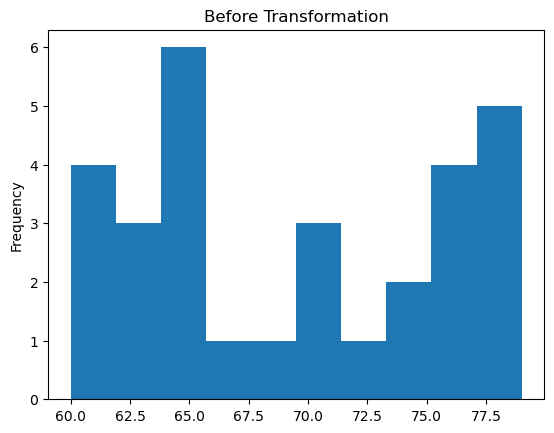

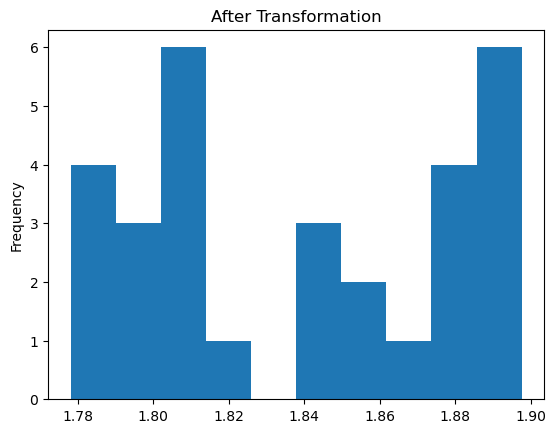

In [15]:
# Before transformation
df['math score'].plot(kind='hist', title='Before Transformation')
plt.show()

# After transformation
df['log_math'].plot(kind='hist', title='After Transformation')
plt.show()